# Kaplan-Meier Curves in Python 

Goal of this notebook is to: 
- Understand the structure of survival data in Python  
- Plot a Kaplan-Meier Curve  
- Plot a Stratified Kaplan-Meier Curve  
- Extract coefficient values from a CoxPH model  
- Evaluate Survival Metrics  

The contents in this notebook are based on the tutorial in [scikit-survival](https://scikit-survival.readthedocs.io/en/stable/user_guide/00-introduction.html#The-Survival-Function). As such, we will be using `scikit-survival` to do our analysis. 

Another popular python package that is popular for survival analysis is `lifelines`. You can find more information about this package: https://lifelines.readthedocs.io/en/latest/Quickstart.html

`lifelines` offers material that closely aligns with what we have done in class up to this point, but does not seem to have a lot of ML methods, so we use `scikit-survival` here.  



## 0. Preliminaries (load data and packages) 


In [1]:
from sksurv.datasets import load_breast_cancer
X, y = load_breast_cancer()
y

array([( True,  723.), (False, 6591.), ( True,  524.), (False, 6255.),
       ( True, 3822.), (False, 6507.), (False, 5947.), (False, 5816.),
       (False, 6007.), ( True, 1233.), ( True, 1136.), (False, 5984.),
       (False, 6249.), ( True, 4066.), ( True,  690.), ( True,  994.),
       ( True,  434.), ( True, 1743.), ( True, 2863.), (False, 5693.),
       (False, 5823.), (False, 5785.), (False, 5661.), (False, 2909.),
       ( True, 1171.), (False, 5110.), (False, 5533.), (False, 5571.),
       (False, 5519.), (False, 5379.), (False, 4675.), (False, 4652.),
       (False, 4227.), ( True,  910.), (False, 4472.), ( True, 1206.),
       (False, 7057.), (False,  958.), (False, 5359.), (False, 5945.),
       (False, 5651.), ( True,  528.), ( True,  796.), (False, 5685.),
       ( True, 1023.), (False, 4791.), (False, 1215.), (False, 3779.),
       (False, 5306.), (False, 5678.), ( True,  421.), (False, 5612.),
       ( True, 3121.), (False, 1104.), (False, 4691.), (False, 5238.),
      

from inspection our `y` variable is an array. If we want to isolate the time and delta, we need to look at `dtype = [('e.tdm', '?'), ('t.tdm', '<f8')]`. 

Now, let's examine the `X` dataframe. Anything that starts with `X...` is a gene. The variables that we may be interested in later are `er` and `grade`. 

In [4]:
X.head()

,X200726_at,X200965_s_at,X201068_s_at,X201091_s_at,X201288_at,X201368_at,X201663_s_at,X201664_at,X202239_at,X202240_at,...,X221344_at,X221634_at,X221816_s_at,X221882_s_at,X221916_at,X221928_at,age,er,grade,size
0,10.926361,8.962608,11.630078,10.964107,11.518305,12.038527,9.623518,9.814798,10.016732,7.847383,...,6.313081,7.842097,10.132635,10.926365,6.477749,5.991885,57.0,negative,poorly differentiated,3.0
1,12.242090,9.531718,12.626106,11.594716,12.317659,10.776911,10.604577,10.704329,10.161838,8.744875,...,5.126765,8.780328,10.213467,9.555092,4.968050,7.051130,57.0,positive,poorly differentiated,3.0
2,11.661716,10.238680,12.572919,9.166088,11.698658,11.353333,9.384927,10.161654,10.032721,8.125487,...,6.936022,7.855649,10.164514,9.308048,4.283777,6.828986,48.0,negative,poorly differentiated,2.5
3,12.174021,9.819279,12.109888,9.086937,13.132617,11.859394,8.400839,8.670721,10.727427,8.650810,...,6.787297,6.678375,10.660092,10.208241,5.713404,6.927251,42.0,positive,poorly differentiated,1.8
4,11.484011,11.489233,11.779285,8.887616,10.429663,11.401139,7.741092,8.642018,9.556686,8.478862,...,7.312287,7.358556,11.570330,10.931843,5.817265,6.655448,46.0,positive,intermediate,3.0


## 1. Plot Kaplan-Meier Curve

Text(0.5, 0, 'time $t$')

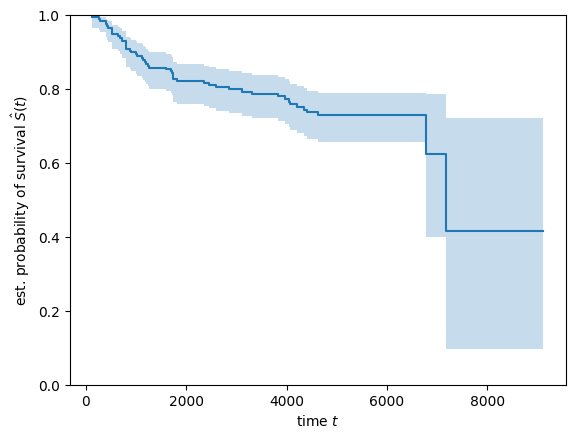

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

time, survival_prob, conf_int = kaplan_meier_estimator(
    y["e.tdm"], y["t.tdm"], conf_type="log-log"
)
plt.step(time, survival_prob, where="post")
plt.fill_between(time, conf_int[0], conf_int[1], alpha=0.25, step="post")
plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")

## 2. Plot a Stratified KM Curve

Before, we identified that `er` status might be worth stratifying on. Let's see what those values look like: 

In [5]:
X["er"].value_counts()

er
positive    134
negative     64
Name: count, dtype: int64

We want to know if there is a difference in survival between the `positive` and `negative` `er` groups. 

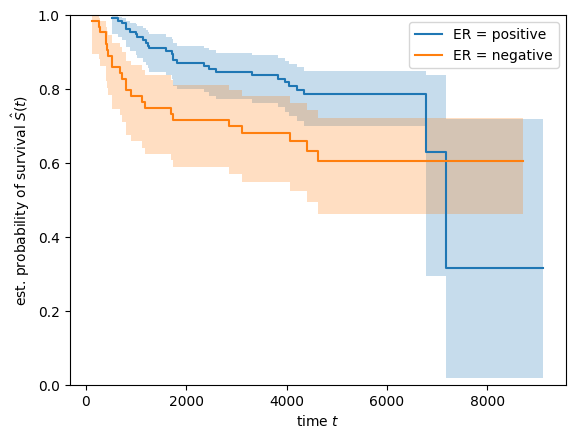

In [6]:
for er_type in ("positive", "negative"):
    mask_er = X["er"] == er_type
    time_treatment, survival_prob_treatment, conf_int = kaplan_meier_estimator(
        y["e.tdm"][mask_er],
        y["t.tdm"][mask_er],
        conf_type="log-log",
    )

    plt.step(time_treatment, survival_prob_treatment, where="post", label=f"ER = {er_type}")
    plt.fill_between(time_treatment, conf_int[0], conf_int[1], alpha=0.25, step="post")

plt.ylim(0, 1)
plt.ylabel(r"est. probability of survival $\hat{S}(t)$")
plt.xlabel("time $t$")
plt.legend(loc="best")

## 3. CoxPH Model  

Before we fit a CoxPH Model, we need to transform the feature matrix (`X`) since we have categorical variables. We can do this using `OneHotEncoder`. 

In [7]:
from sksurv.preprocessing import OneHotEncoder

Xt = OneHotEncoder().fit_transform(X)
Xt.head()

,X200726_at,X200965_s_at,X201068_s_at,X201091_s_at,X201288_at,X201368_at,X201663_s_at,X201664_at,X202239_at,X202240_at,...,X221816_s_at,X221882_s_at,X221916_at,X221928_at,age,er=positive,grade=intermediate,grade=poorly differentiated,grade=unkown,size
0,10.926361,8.962608,11.630078,10.964107,11.518305,12.038527,9.623518,9.814798,10.016732,7.847383,...,10.132635,10.926365,6.477749,5.991885,57.0,0.0,0.0,1.0,0.0,3.0
1,12.242090,9.531718,12.626106,11.594716,12.317659,10.776911,10.604577,10.704329,10.161838,8.744875,...,10.213467,9.555092,4.968050,7.051130,57.0,1.0,0.0,1.0,0.0,3.0
2,11.661716,10.238680,12.572919,9.166088,11.698658,11.353333,9.384927,10.161654,10.032721,8.125487,...,10.164514,9.308048,4.283777,6.828986,48.0,0.0,0.0,1.0,0.0,2.5
3,12.174021,9.819279,12.109888,9.086937,13.132617,11.859394,8.400839,8.670721,10.727427,8.650810,...,10.660092,10.208241,5.713404,6.927251,42.0,1.0,0.0,1.0,0.0,1.8
4,11.484011,11.489233,11.779285,8.887616,10.429663,11.401139,7.741092,8.642018,9.556686,8.478862,...,11.570330,10.931843,5.817265,6.655448,46.0,1.0,1.0,0.0,0.0,3.0


You use that the `Xt` matrix for the `fit` function:

In [10]:
import pandas as pd
from sklearn import set_config
from sksurv.linear_model import CoxPHSurvivalAnalysis

set_config(display="text")  # displays text representation of estimators

estimator = CoxPHSurvivalAnalysis()
estimator.fit(Xt, y)

CoxPHSurvivalAnalysis()

In [11]:
pd.Series(estimator.coef_, index=Xt.columns)

X200726_at                     -4.034343
X200965_s_at                    0.702673
X201068_s_at                   -3.842316
X201091_s_at                   -2.752625
X201288_at                      0.802856
                                 ...    
er=positive                    -2.429159
grade=intermediate              4.932327
grade=poorly differentiated     3.362598
grade=unkown                  -16.889889
size                            0.804356
Length: 82, dtype: float64

In [ ]:
from sksurv.metrics import concordance_index_censored

prediction = estimator.predict(Xt)
result = concordance_index_censored(y["e.tdm"], y["t.tdm"], prediction)
f"{result[0]:.5f}"


'0.95013'

or alternatively, 

In [13]:
c_index = estimator.score(Xt, y)
f"{c_index:.5f}"

'0.95013'